In [1]:
import numpy as np
from tqdm import tqdm
import time
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# TORCH MODULES FOR METRICS COMPUTATION :
import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MultilabelF1Score
from torchmetrics.classification import MultilabelAccuracy

MAIN_DIR = '/kaggle/input/cafa-6-protein-function-prediction'

class config:
    train_sequences_path = MAIN_DIR  + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test/testsuperset.fasta"
    
    num_labels = 500
    n_epochs = 5
    batch_size = 128
    lr = 0.01
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class ProteinSequenceDataset(Dataset):
    
    def __init__(self, train_emb, train_id, top, datatype):
        super(ProteinSequenceDataset).__init__()
        
        self.datatype = datatype
        embeds = np.load(train_emb)
        ids = np.load(train_id)
            
        embeds_list = []
        for l in range(embeds.shape[0]):
            embeds_list.append(embeds[l,:])
        self.df = pd.DataFrame(data={"EntryID": ids, "embed" : embeds_list})
        
        if datatype=="train":
            np_labels = np.load(top)
            df_labels = pd.DataFrame(self.df['EntryID'])
            df_labels['labels_vect']=[row for row in np_labels]
            self.df = self.df.merge(df_labels, on="EntryID")
            
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"] , dtype = torch.float32)
        if self.datatype=="train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype = torch.float32)
            return embed, targets
        if self.datatype=="test":
            id = self.df.iloc[index]["EntryID"]
            return embed, id

In [3]:
name = ""
dataset = "/kaggle/input/cafa-6-ems-embedding-dataset"
top = "/kaggle/input/cafa6top500/train_targets_top500.npy"

train_emb = f"{dataset}/train{name}_embeddings.npy"
train_id = f"{dataset}/train{name}_ids.npy"
test_emb = f"{dataset}/test{name}_embeddings.npy"
test_id = f"{dataset}/test{name}_ids.npy"

train_dataset_6 = ProteinSequenceDataset(train_emb, train_id, top, datatype="train")
test_dataset_6 = ProteinSequenceDataset(test_emb, test_id, top, datatype="test")

In [4]:
train_dataset_6

In [5]:
import torch
import torch.nn as nn
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, x):
        batch_size, seq_len, d_model = x.size()
        
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        attention_output = torch.matmul(attention_weights, V)
        
        attention_output = attention_output.transpose(1, 2).contiguous()
        attention_output = attention_output.view(batch_size, seq_len, d_model)
        
        output = self.out_proj(attention_output)
        
        return output, attention_weights


class MLPWithMultiHeadAttention(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=512, num_heads=8, num_attention_blocks=3):
        super(MLPWithMultiHeadAttention, self).__init__()
        
        self.input_projection = nn.Linear(input_dim, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, 1, d_model))
        
        self.attention_blocks = nn.ModuleList([
            nn.ModuleDict({
                'attention': MultiHeadAttention(d_model, num_heads, dropout=0.1),
                'norm1': nn.LayerNorm(d_model),
                'ffn': nn.Sequential(
                    nn.Linear(d_model, d_model * 4),
                    nn.GELU(),
                    nn.Dropout(0.1),
                    nn.Linear(d_model * 4, d_model),
                    nn.Dropout(0.1)
                ),
                'norm2': nn.LayerNorm(d_model)
            })
            for _ in range(num_attention_blocks)
        ])
        
        self.mlp_head = nn.Sequential(
            nn.Linear(d_model, 864),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(864, 712),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(712, num_classes)
        )
        
    def forward(self, x):
        x = self.input_projection(x)
        x = x.unsqueeze(1)
        x = x + self.positional_encoding
        
        attention_weights_list = []
        for block in self.attention_blocks:
            attn_output, attn_weights = block['attention'](x)
            x = block['norm1'](x + attn_output)
            
            ffn_output = block['ffn'](x)
            x = block['norm2'](x + ffn_output)
            
            attention_weights_list.append(attn_weights)
        
        x = x.squeeze(1)
        output = self.mlp_head(x)
        
        return output


class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MultiLayerPerceptron, self).__init__()
        
        self.feature_layer1 = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.attention1 = MultiHeadAttention(d_model=512, num_heads=8, dropout=0.1)
        self.norm1 = nn.LayerNorm(512)
        
        self.feature_layer2 = nn.Sequential(
            nn.Linear(512, 864),
            nn.LayerNorm(864),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.attention2 = MultiHeadAttention(d_model=864, num_heads=12, dropout=0.1)
        self.norm2 = nn.LayerNorm(864)
        
        self.classifier = nn.Sequential(
            nn.Linear(864, 712),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(712, num_classes)
        )
        
    def forward(self, x, return_attention=False):
        x = self.feature_layer1(x)
        
        x = x.unsqueeze(1)
        attn_out1, attn_weights1 = self.attention1(x)
        x = self.norm1(x + attn_out1)
        
        x = x.squeeze(1)
        x = self.feature_layer2(x)
        
        x = x.unsqueeze(1)
        attn_out2, attn_weights2 = self.attention2(x)
        x = self.norm2(x + attn_out2)
        x = x.squeeze(1)
        
        output = self.classifier(x)
        
        if return_attention:
            return output, (attn_weights1, attn_weights2)
        return output

In [6]:
def train_model(model, train_size=0.9):

    train_set_6, val_set_6 = random_split(train_dataset_6, lengths = [int(len(train_dataset_6)*train_size), len(train_dataset_6)-int(len(train_dataset_6)*train_size)])
    train_dataloader_6 = torch.utils.data.DataLoader(train_set_6, batch_size=config.batch_size, shuffle=True)
    val_dataloader_6 = torch.utils.data.DataLoader(val_set_6, batch_size=config.batch_size, shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr = config.lr)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=1)
    CrossEntropy = torch.nn.BCEWithLogitsLoss()
    f1_score = MultilabelF1Score(num_labels=config.num_labels).to(config.device)
    n_epochs = config.n_epochs

    print("BEGIN TRAINING WITH ESM2 EMBEDDINGS...")
    train_loss_history=[]
    val_loss_history=[]
    
    train_f1score_history=[]
    val_f1score_history=[]
    for epoch in range(n_epochs):
        print("EPOCH ", epoch+1)
        ## TRAIN PHASE :
        losses = []
        scores = []
        
        for embed, targets in tqdm(train_dataloader_6):
            embed, targets = embed.to(config.device), targets.to(config.device)
            optimizer.zero_grad()
            preds = model(embed)
            loss= CrossEntropy(preds, targets)
            score=f1_score(preds, targets)
            losses.append(loss.item()) 
            scores.append(score.item())
            loss.backward()
            optimizer.step()
             
        avg_loss = np.mean(losses)
        avg_score = np.mean(scores)
        print("Running Average TRAIN Loss : ", avg_loss)
        print("Running Average TRAIN F1-Score : ", avg_score)
        train_loss_history.append(avg_loss)
        train_f1score_history.append(avg_score)
        
        ## VALIDATION PHASE : 
        losses = []
        scores = []
        for embed, targets in val_dataloader_6:
            embed, targets = embed.to(config.device), targets.to(config.device)
            preds = model(embed)
            loss= CrossEntropy(preds, targets)
            score=f1_score(preds, targets)
            losses.append(loss.item())
            scores.append(score.item())
            
        avg_loss = np.mean(losses)
        avg_score = np.mean(scores)
        print("Running Average VAL Loss : ", avg_loss)
        print("Running Average VAL F1-Score : ", avg_score)
        val_loss_history.append(avg_loss)
        val_f1score_history.append(avg_score)
        
        scheduler.step(avg_loss)
        print("\n")
        
    print("TRAINING FINISHED")
    print("FINAL TRAINING SCORE : ", train_f1score_history[-1])
    print("FINAL VALIDATION SCORE : ", val_f1score_history[-1])
    
    losses_history = {"train" : train_loss_history, "val" : val_loss_history}
    scores_history = {"train" : train_f1score_history, "val" : val_f1score_history}
    
    return model, losses_history, scores_history

model = MultiLayerPerceptron(input_dim=1024, num_classes=config.num_labels).to(config.device)

esm2_model, esm2_losses, esm2_scores = train_model(model)

BEGIN TRAINING WITH ESM2 EMBEDDINGS...
EPOCH  1


100%|██████████| 580/580 [01:12<00:00,  8.00it/s]


Running Average TRAIN Loss :  0.037675006902808776
Running Average TRAIN F1-Score :  0.00017079485652833807
Running Average VAL Loss :  0.03461448805263409
Running Average VAL F1-Score :  1.1242201323441874e-05


EPOCH  2


100%|██████████| 580/580 [01:20<00:00,  7.19it/s]


Running Average TRAIN Loss :  0.033602396357033784
Running Average TRAIN F1-Score :  2.8201105594454367e-05
Running Average VAL Loss :  0.033447225907674204
Running Average VAL F1-Score :  0.0


EPOCH  3


...

Running Average TRAIN Loss :  0.03286547142819598
Running Average TRAIN F1-Score :  2.081895406169271e-06
Running Average VAL Loss :  0.03316531737263386
Running Average VAL F1-Score :  0.0


EPOCH  4


100%|██████████| 580/580 [01:09<00:00,  8.30it/s]


Running Average TRAIN Loss :  0.03242849238409565
Running Average TRAIN F1-Score :  3.39765530701823e-06
Running Average VAL Loss :  0.03296993182828793
Running Average VAL F1-Score :  1.0430247549755643e-06


EPOCH  5


100%|██████████| 580/580 [01:09<00:00,  8.38it/s]


Running Average TRAIN Loss :  0.0320960459716875
Running Average TRAIN F1-Score :  7.833099303313468e-06
Running Average VAL Loss :  0.032474494668153615
Running Average VAL F1-Score :  0.0


TRAINING FINISHED
FINAL TRAINING SCORE :  7.833099303313468e-06
FINAL VALIDATION SCORE :  0.0


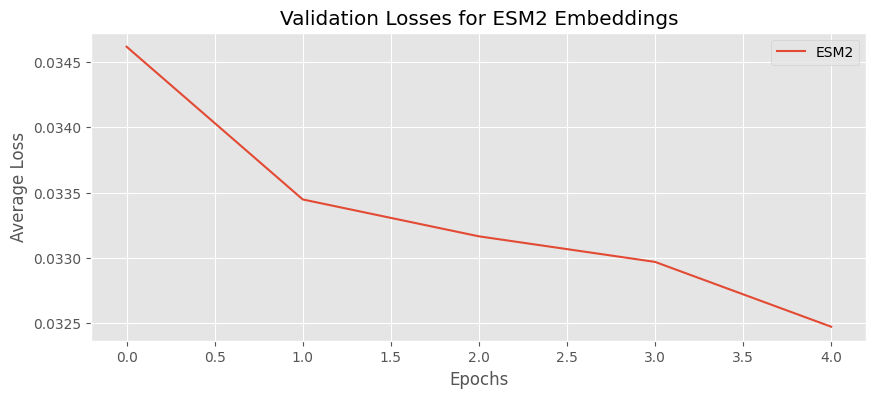

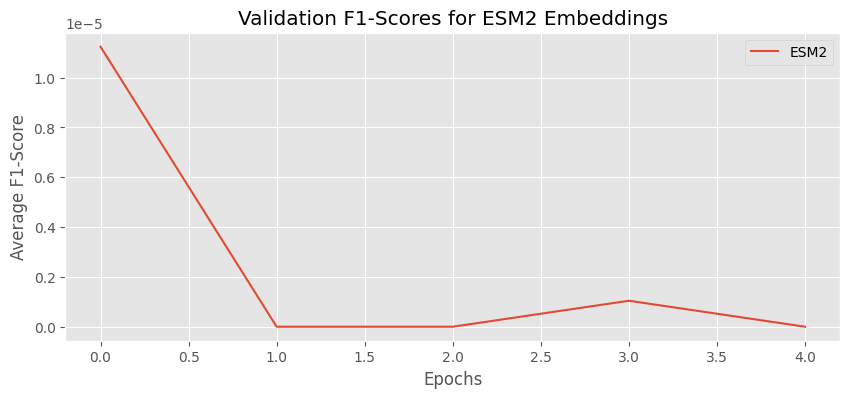

In [7]:
plt.figure(figsize = (10, 4))
plt.plot(esm2_losses["val"], label = "ESM2") 
plt.title("Validation Losses for ESM2 Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(esm2_scores["val"], label = "ESM2")
plt.title("Validation F1-Scores for ESM2 Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average F1-Score")
plt.legend()
plt.show()

In [8]:
def predict(test_dataset):
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    model = esm2_model
    model.eval()
    
    labels = pd.read_csv(config.train_labels_path, sep = "\t")
    top_terms = labels.groupby("term")["EntryID"].count().sort_values(ascending=False)
    labels_names = top_terms[:config.num_labels].index.values
    print("GENERATE PREDICTION FOR TEST SET...")

    ids_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    go_terms_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    confs_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=np.float32)

    for i, (embed, id) in tqdm(enumerate(test_dataloader)):
        embed = embed.to(config.device)
        confs_[i*config.num_labels:(i+1)*config.num_labels] = torch.nn.functional.sigmoid(model(embed)).squeeze().detach().cpu().numpy()
        ids_[i*config.num_labels:(i+1)*config.num_labels] = id[0]
        go_terms_[i*config.num_labels:(i+1)*config.num_labels] = labels_names

    submission_df = pd.DataFrame(data={"Id" : ids_, "GO term" : go_terms_, "Confidence" : confs_})
    print("PREDICTIONS DONE")
    return submission_df

submission_df = predict(test_dataset_6)

submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)

GENERATE PREDICTION FOR TEST SET...


224309it [15:03, 248.21it/s]


PREDICTIONS DONE
